In [1]:
import pandas as pd
df = pd.read_csv("train.csv")

# Basic look on the Data

In [2]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Checking Patterns

In [6]:
df["Survived"].value_counts(normalize = True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [7]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [8]:
df["Pclass"].value_counts(normalize = True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [9]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [10]:
pd.crosstab(df["Pclass"], df["Survived"], normalize="index")

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [45]:
pd.crosstab(df["Age"], df["Survived"])

Survived,0,1
Age,,
0.42,0,1
0.67,0,1
0.75,0,2
0.83,0,2
0.92,0,1
...,...,...
70.00,2,0
70.50,1,0
71.00,2,0


In [12]:
df.groupby(pd.cut(df["Age"], bins=[0,12,18,35,60,100]))["Survived"].mean()

Age
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

## Different ways to get same result

Method 1

In [13]:
pd.crosstab(
    [df["Pclass"], df["Sex"]],
    df["Survived"],
    normalize="index"
)

Survived              0         1
Pclass Sex                       
1      female  0.031915  0.968085
       male    0.631148  0.368852
2      female  0.078947  0.921053
       male    0.842593  0.157407
3      female  0.500000  0.500000
       male    0.864553  0.135447

Method 2

In [14]:
df.groupby(["Sex", "Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [44]:
df.groupby(["Sex", "Pclass", pd.cut(df["Age"], bins=[0,12,18,35,60,100])])["Survived"].mean()

Sex     Pclass  Age      
female  1       (0, 12]      0.000000
                (12, 18]     1.000000
                (18, 35]     0.972222
                (35, 60]     0.972222
                (60, 100]    1.000000
        2       (0, 12]      1.000000
                (12, 18]     1.000000
                (18, 35]     0.925000
                (35, 60]     0.850000
        3       (0, 12]      0.478261
                (12, 18]     0.550000
                (18, 35]     0.500000
                (35, 60]     0.142857
                (60, 100]    1.000000
male    1       (0, 12]      1.000000
                (12, 18]     0.500000
                (18, 35]     0.500000
                (35, 60]     0.370370
                (60, 100]    0.083333
        2       (0, 12]      1.000000
                (12, 18]     0.000000
                (18, 35]     0.074074
                (35, 60]     0.037037
                (60, 100]    0.333333
        3       (0, 12]      0.360000
                (12, 18]

In [29]:
df.loc[(df['Age'] <= 12) & (df['Pclass'] == 1), ['Name', 'Sex', 'Pclass', 'Survived']]

,Name,Sex,Pclass,Survived
297,"Allison, Miss. Helen Loraine",female,1,0
305,"Allison, Master. Hudson Trevor",male,1,1
445,"Dodge, Master. Washington",male,1,1
802,"Carter, Master. William Thornton II",male,1,1


In [30]:
df.loc[(df['Age'] <= 12) & (df['Pclass'] == 2), ['Name', 'Sex', 'Pclass', 'Survived']]

,Name,Sex,Pclass,Survived
43,"Laroche, Miss. Simonne Marie Anne Andree",female,2,1
58,"West, Miss. Constance Mirium",female,2,1
78,"Caldwell, Master. Alden Gates",male,2,1
183,"Becker, Master. Richard F",male,2,1
193,"Navratil, Master. Michel M",male,2,1
237,"Collyer, Miss. Marjorie ""Lottie""",female,2,1
340,"Navratil, Master. Edmond Roger",male,2,1
407,"Richards, Master. William Rowe",male,2,1
530,"Quick, Miss. Phyllis May",female,2,1
535,"Hart, Miss. Eva Miriam",female,2,1


In [36]:
df.loc[(df['Age'] <= 12) & (df['Pclass'] == 1), 
       ['Name', 'Sex', 'Pclass', 'Survived']
      ].sort_values(by='Survived', ascending=False)

,Name,Sex,Pclass,Survived
305,"Allison, Master. Hudson Trevor",male,1,1
445,"Dodge, Master. Washington",male,1,1
802,"Carter, Master. William Thornton II",male,1,1
297,"Allison, Miss. Helen Loraine",female,1,0


Method 3

In [15]:
df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack()

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


# Basic Visualization for observing patterns with ease

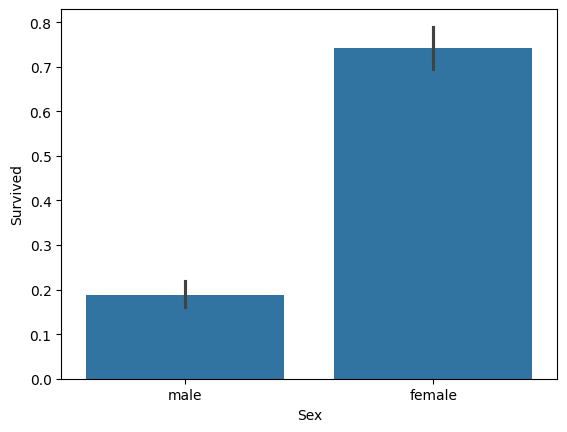

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x = "Sex", y = "Survived", data = df)
plt.show()

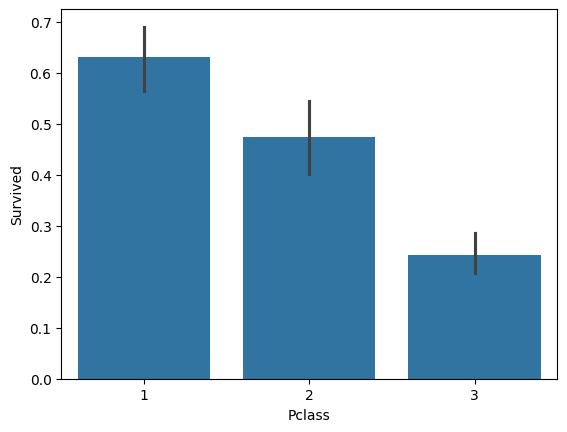

In [40]:
sns.barplot(x = "Pclass", y = "Survived", data = df)
plt.show()

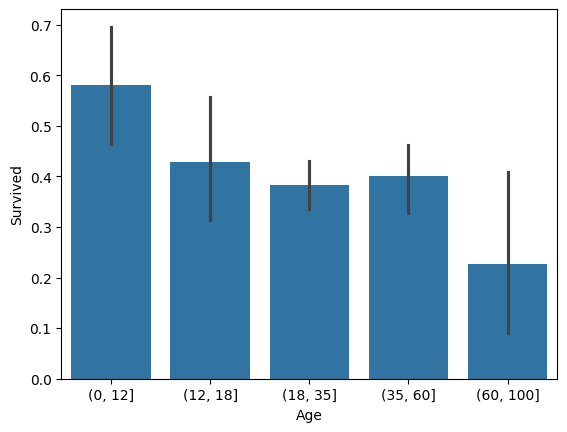

In [39]:
sns.barplot(x = pd.cut(df["Age"], bins=[0,12,18,35,60,100]), y = "Survived", data = df)
plt.show()

In [17]:
df = df[["Survived", "Sex", "Pclass", "Age"]]

In [18]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [19]:
print(df["Sex"].iloc[0])
print(type(df["Sex"].iloc[0]))

print(df["Sex"].map({"male": 0, "female": 1}).head())

male
<class 'str'>
0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64


## Debugging Learnings

- Always use `.copy()` when creating subset DataFrames
- `.map()` returns NaN if values don’t match exactly
- Avoid `inplace=True` with chained operations
- Use assignment instead of inplace operations

In [20]:
df = df[["Survived", "Pclass", "Sex", "Age"]]
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [21]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df

,Survived,Pclass,Sex,Age
0,0,3,0,22.0
1,1,1,1,38.0
2,1,3,1,26.0
3,1,1,1,35.0
4,0,3,0,35.0
...,...,...,...,...
886,0,2,0,27.0
887,1,1,1,19.0
888,0,3,1,28.0
889,1,1,0,26.0


# A little modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.770949720670391